### Analyzing Text About Data Science.

In [1]:
# extract text from Wikipedia about data science

url = "https://en.wikipedia.org/wiki/Data_science"

#### Getting the data

In [4]:
# getting the data
import requests
# define a custom header

headers = {
    "User-Agent": "DataScienceChallenge/1.0 (myemail@gmail.com)"
}

# pass the header into the get request
response = requests.get(url, headers=headers)
if response.status_code == 200:
    text = response.content.decode("utf-8")
    print(text[:1000])
else:
    print(f"Error: {response.status_code}")

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Data science - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-

#### transforming the data

In [5]:
import sys
!{sys.executable} -m pip install beautifulsoup4

In [16]:
from bs4 import BeautifulSoup
# parse the HTML content
soup = BeautifulSoup(text, "html.parser")
# Extract only the main article content from Wikipedia
# Wikipedia uses 'mw-parser-output' class for the main article content
content = soup.find('div', class_='mw-parser-output')

def clean_wikipedia_content(content_node):
    """Remove common non-article elements from a Wikipedia content node."""
    # Strip jump links, navboxes, reference lists/superscripts, edit sections, TOC, sidebars, etc.
    selectors = [
        '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar',
    ]
    for selector in selectors:
        for el in content_node.select(selector):
            el.decompose()
if content:
    # claen the content node to better approximate tetx only.
    clean_wikipedia_content(content)
    text = content.get_text(separator=" ", strip=True)
    print(text[:1000])
else:
    print("could not find main content. using full page text.")
    text = soup.get_text(separator=" ", strip=True)
    print(text[:1000])
            

Field of study to extract knowledge from data The existence of Comet NEOWISE (here depicted as a series of red dots) was discovered by analyzing astronomical survey data acquired by a space telescope , the Wide-field Infrared Survey Explorer . Data science is an interdisciplinary academic field that uses statistics , scientific computing , scientific methods , processing, scientific visualization , algorithms , coding (like Python, SQL, and R), and systems to extract or extrapolate knowledge from potentially noisy, structured , or unstructured data . A data scientist is a professional who creates programming code and combines it with statistical knowledge to summarize data. Scope of data science Data science plays a critical role in modern decision-making by enabling organizations to extract actionable insights from large and complex datasets. Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medici

### Getting data insights

In [17]:
# we use RAKE for keyword extraction
!{sys.executable} -m pip install nlp_rake

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     -------------------- ----------------- 524.3/981.5 kB 1.1 MB/s eta 0:00:01
     -------------------- ----------------- 524.3/981.5 kB 1.1 MB/s eta 0:00:01
     -------------------- ----------------- 524.3/981.5 kB 1.1 MB/s eta 0:00:01
     ---------------------------- ------- 786.4/981.5 kB 624.9 kB/s eta 0:00:01
     ---------------------------- ------- 786.4/981.5 kB 624.9 kB/s eta 0:00:01
     --------------------------------------- 981.5/981.5 kB 514.0 kB/s  0:00:02
  Installing build dependencies: started
  Installing build dependencies: finish

In [18]:
import nlp_rake 
extractor = nlp_rake.Rake(max_words=2, min_freq=3,min_chars=5)
res = extractor.apply(text)
res

[('data scientist', 4.0),
 ('sexiest job', 4.0),
 ('21st century', 4.0),
 ('statistical learning', 4.0),
 ('big data', 4.0),
 ('data science', 3.9),
 ('computer science', 3.9),
 ('information science', 3.809090909090909),
 ('↑ davenport', 3.8),
 ('cloud computing', 3.75),
 ('data analysis', 3.7),
 ('science', 1.9),
 ('analysis', 1.7),
 ('statistics', 1.2666666666666666),
 ('processing', 1.25),
 ('thomas', 1.2),
 ('field', 1.0),
 ('techniques', 1.0),
 ('education', 1.0),
 ('communications', 1.0),
 ('chikio', 1.0),
 ('bibcode', 1.0)]

### Visualize the results

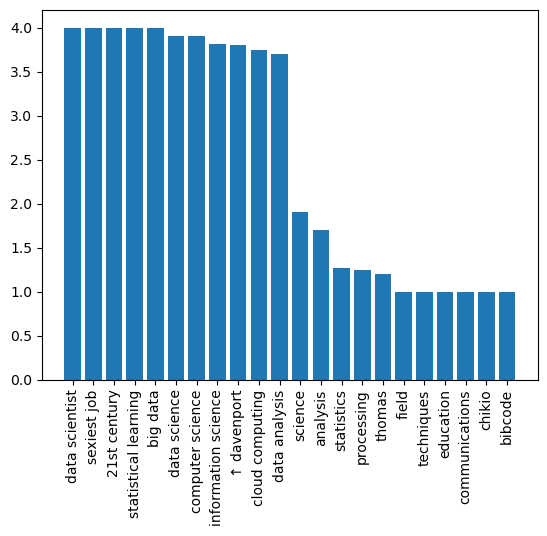

In [30]:
import matplotlib.pyplot as plt

def plot(pair_list):
    k,v = zip(*pair_list)
    plt.bar(range(len(k)),v)
    plt.xticks(range(len(k)),k,rotation='vertical')
    plt.show()

plot(res[:30])

### Visualize using wordcloud 

In [20]:
!{sys.executable} -m pip install wordcloud

  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl (306 kB)


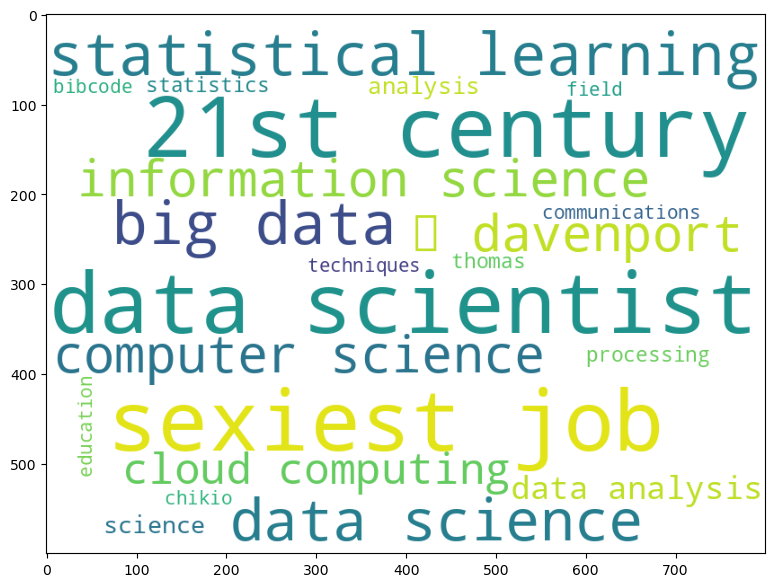

In [22]:
from wordcloud import WordCloud

wc = WordCloud(background_color="white", width=800, height=600)
plt.figure(figsize=(15,7))
plt.imshow(wc.generate_from_frequencies({ k:v for k,v in res}))

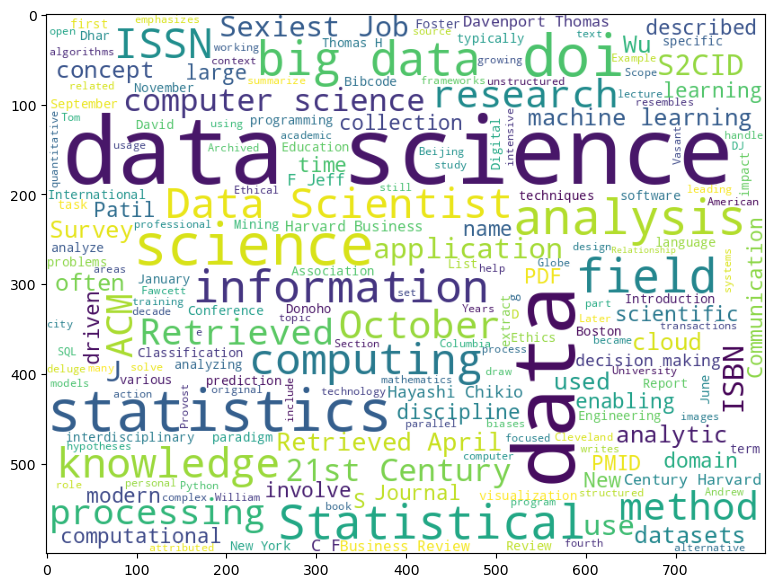

In [23]:
# pass the original text to wordcloud

plt.figure(figsize=(15,7))
plt.imshow(wc.generate(text))

In [27]:
#wc.generate(text).to_file('Learning-Data-Science/ds_wordcloud.png')